# Lecture : Shallow Graph Learning

## Lab 02 : Graph Classification with Graphlet Kernel -- Solution

### Xavier Bresson


In this notebook we classify the 8 graph classes of DGL's `MiniGCDataset` using the **9 connected graphlets on 2, 3, and 4 nodes**:

$$
1 + 2 + 6 = 9.
$$

The graphlets are

$$
G_0,\ldots,G_8
=
\{\text{edge},\ P_3,\ K_3,\ P_4,\ K_{1,3},\ C_4,\ \text{tailed triangle},\ K_4-\text{edge},\ K_4\}.
$$

<div align="center">
  <img src="pic/graphlets.png" width="50%">
</div>

For each graph $G$, let $c_j(G)$ be the number of induced occurrences of graphlet $G_j$.

Because the graphlets have different sizes, we normalize every count by the number of possible node subsets of the corresponding size:

$$
\phi_j(G)
=
\frac{c_j(G)}
{\binom{|G|}{|G_j|}},
$$
where $\binom{p}{q}$ is the number of ways to choose q elements from a set of p elements, $|G|$ is the number of nodes in the full graph $G$, and $|G_j|$ is the number of nodes in graphlet $G_j$.

Thus, each graph is represented by a fixed **9-dimensional graphlet feature vector**:

$$
\phi(G)
=
[\phi_0(G),\ldots,\phi_8(G)]^\top\in\mathbb{N}^9.
$$

We then define the normalized **graphlet kernel**:

$$
K(G,G')
=
\frac{\phi(G)^\top \phi(G')}{\|\phi(G)\|_2\,\|\phi(G')\|_2}\in[0,1]
$$

and train with a kernel SVM model.

Note: The nine graphlets used here are the standard connected graphlets $G_0,\ldots,G_8$ on 2–4 nodes. **Disconnected induced subgraphs are ignored.**


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/05_Shallow_Learning'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip -q install dgl==1.0.2 # install DGL library
    

In [2]:
import itertools
import math
import time
import dgl
from dgl.data import MiniGCDataset
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

CLASS_NAMES = [
    "cycle",
    "star",
    "wheel",
    "lollipop",
    "hypercube",
    "grid",
    "clique",
    "circular ladder",
]


## Step 1 : Generate and visualize the 8 graph classes

Number of graphs: 640
Graphs per class: [80 80 80 80 80 80 80 80]


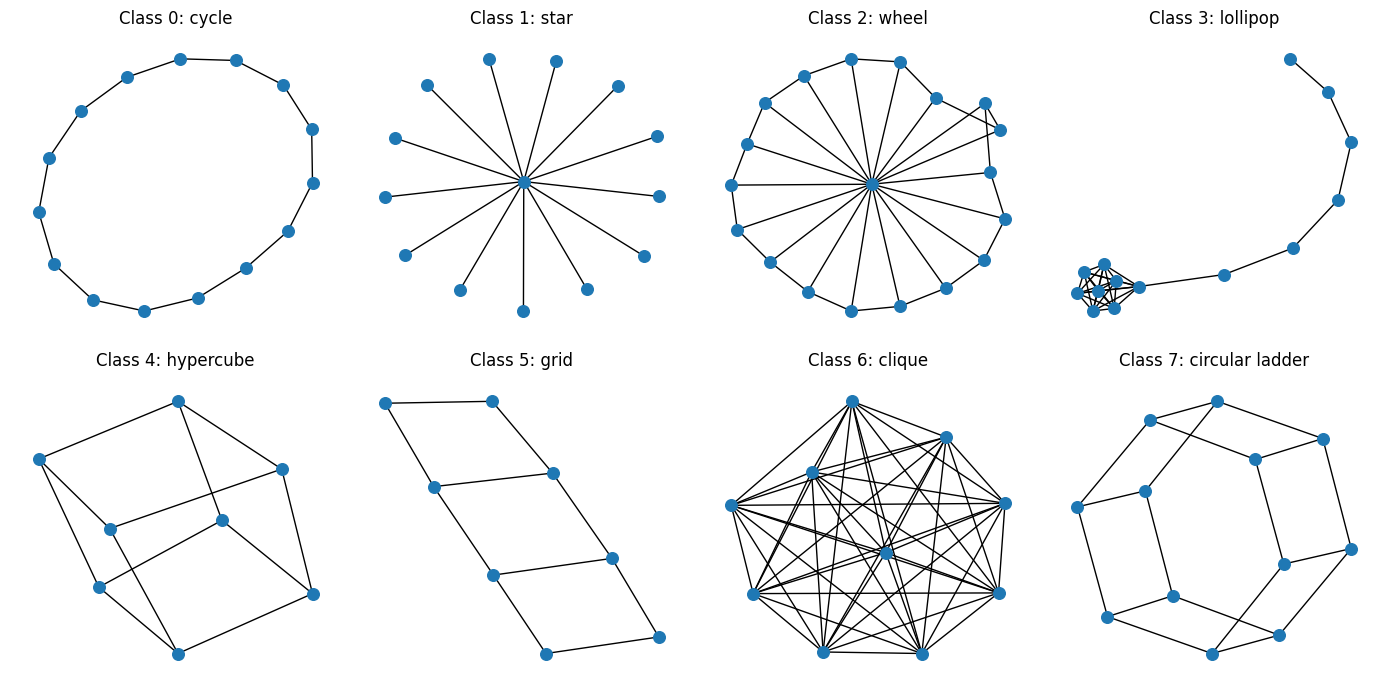

In [3]:
# Generate a dataset of 640 graphs, with random size between 10 and 20 nodes
dataset = MiniGCDataset(640, 10, 20)
# print('dataset:', dataset)
labels = np.array([int(dataset[i][1]) for i in range(len(dataset))]) # labels = [0 .. 0, 1 .. 1, .. , 7 .. 7]
# print('labels.shape:', labels.shape, labels) # (640,)
print("Number of graphs:", len(dataset)) # 640
print("Graphs per class:", np.bincount(labels)) # [80 80 80 80 80 80 80 80]

def dgl_to_simple_nx(g):
    G = nx.Graph(g.to_networkx())
    G.remove_edges_from(nx.selfloop_edges(G)) # MiniGCDataset adds self-loops.
                                              # Graphlets are defined on undirected graphs, so we remove self-loops.
    return nx.convert_node_labels_to_integers(G)

# Visualize one example from each class
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for c, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(labels == c)[0]
    G = dgl_to_simple_nx(dataset[idx][0])
    nx.draw(G, ax=ax, node_size=70, width=1.0)
    ax.set_title(f"Class {c}: {CLASS_NAMES[c]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


## Step 2 : Define the 9 graphlets

The nine graphlets are all **connected, non-isomorphic, induced** graphlets on 2–4 nodes:

- \(G_0\): edge
- \(G_1\): 3-node path \(P_3\)
- \(G_2\): triangle \(K_3\)
- \(G_3\): 4-node path \(P_4\)
- \(G_4\): 3-star \(K_{1,3}\)
- \(G_5\): 4-cycle \(C_4\)
- \(G_6\): tailed triangle
- \(G_7\): diamond \(K_4-edge\)
- \(G_8\): 4-clique \(K_4\)

To recognize these graphlets efficiently, we encode the adjacency pattern of each small induced subgraph as a bit mask. For a graphlet with k nodes, there are $\binom{k}{2}$ possible undirected edges. Each possible edge is assigned one bit: bit =1 if the edge is present, bit =0 if the edge is absent. For example, a 4-node subgraph has $\binom{4}{2}=6$ possible edges, so its structure can be represented by a 6-bit binary number.

Different node orderings can produce different bit masks for the same graph structure. To remove this dependence on node labels, we consider all permutations of the nodes and choose a single canonical bit mask: the smallest mask obtained over all permutations. 

Therefore, two induced subgraphs have the same canonical bit mask **if and only if they are isomorphic**. We can then identify a sampled graphlet by computing its canonical mask and looking it up in a dictionary, instead of repeatedly running a more expensive graph-isomorphism test.


Selected graphlets:
  G0: edge               k=2, canonical mask=1
  G1: P3                 k=3, canonical mask=3
  G2: triangle           k=3, canonical mask=7
  G3: P4                 k=4, canonical mask=13
  G4: 3-star             k=4, canonical mask=7
  G5: C4                 k=4, canonical mask=30
  G6: tailed triangle    k=4, canonical mask=15
  G7: diamond            k=4, canonical mask=31
  G8: K4                 k=4, canonical mask=63


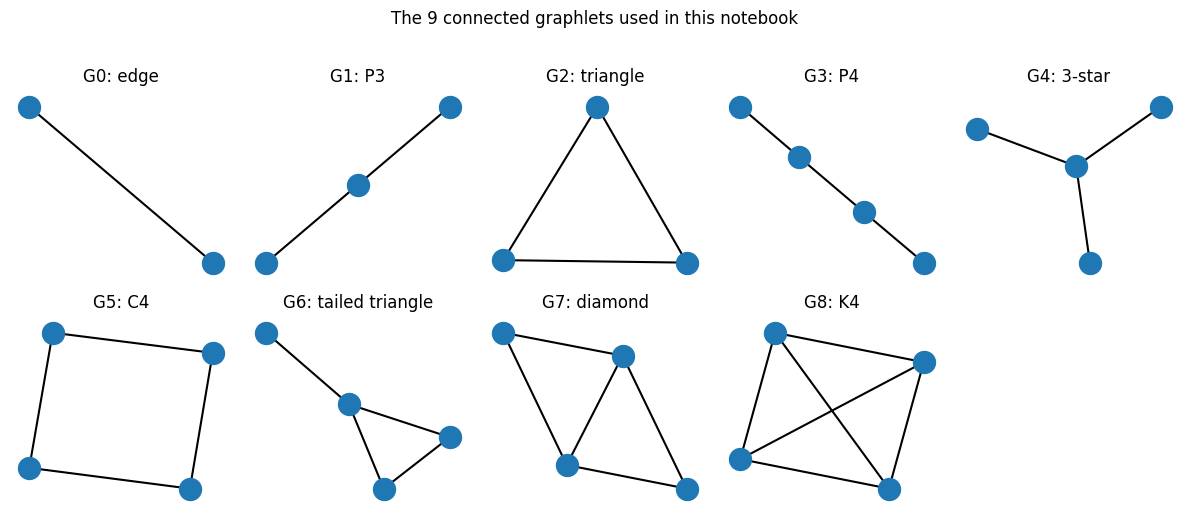

In [4]:
GRAPHLET_NAMES = [
    "G0: edge",
    "G1: P3",
    "G2: triangle",
    "G3: P4",
    "G4: 3-star",
    "G5: C4",
    "G6: tailed triangle",
    "G7: diamond",
    "G8: K4",
]

GRAPHLET_SIZES = np.array([2, 3, 3, 4, 4, 4, 4, 4, 4])

# Prototype edge lists for G0,...,G8
GRAPHLET_EDGES = [
    [(0, 1)],
    [(0, 1), (1, 2)],
    [(0, 1), (1, 2), (0, 2)],
    [(0, 1), (1, 2), (2, 3)],
    [(0, 1), (0, 2), (0, 3)],
    [(0, 1), (1, 2), (2, 3), (3, 0)],
    [(0, 1), (1, 2), (2, 0), (2, 3)],
    [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3)],
    list(itertools.combinations(range(4), 2)),
]

def edge_pairs(k):
    return list(itertools.combinations(range(k), 2))

def graph_to_mask(G, k):
    mask = 0
    for bit, (u, v) in enumerate(edge_pairs(k)):
        if G.has_edge(u, v):
            mask |= 1 << bit
    return mask

def permuted_mask(mask, k, perm):
    pairs = edge_pairs(k)
    pair_to_bit = {
        e: b
        for b, e in enumerate(pairs)
    }
    new_mask = 0
    for new_bit, (i, j) in enumerate(pairs):
        old_i = perm[i]
        old_j = perm[j]
        if old_i > old_j:
            old_i, old_j = old_j, old_i
        old_bit = pair_to_bit[ (old_i, old_j) ]
        if (mask >> old_bit) & 1:
            new_mask |= 1 << new_bit
    return new_mask

def canonical_mask(mask, k):
    return min( permuted_mask(mask, k, perm) for perm in itertools.permutations(range(k)) )

def prototype_canonical_mask(k, edges):
    G = nx.Graph()
    G.add_nodes_from(range(k))
    G.add_edges_from(edges)
    return canonical_mask(graph_to_mask(G, k), k)

# Canonical key for each of the nine selected graphlets.
GRAPHLET_KEYS_9 = []

for j, (k, edges) in enumerate( zip(GRAPHLET_SIZES, GRAPHLET_EDGES) ):
    key = prototype_canonical_mask(int(k), edges)
    GRAPHLET_KEYS_9.append((int(k), key))

print("Selected graphlets:")
for j, ((k, key), name) in enumerate( zip( GRAPHLET_KEYS_9, GRAPHLET_NAMES ) ):
    print(f"  {name:22s} "
          f"k={k}, canonical mask={key}")

# Visualize exactly the nine graphlets used by the kernel.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for j in range(9):
    k = int(GRAPHLET_SIZES[j])
    H = nx.Graph()
    H.add_nodes_from(range(k))
    H.add_edges_from(GRAPHLET_EDGES[j])
    pos = nx.spring_layout(H)
    nx.draw(H, pos, ax=axes[j], node_size=250, width=1.5, with_labels=False)
    axes[j].set_title(GRAPHLET_NAMES[j])
    axes[j].axis("off")
axes[9].axis("off")
plt.suptitle("The 9 connected graphlets used in this notebook", y=1.02)
plt.tight_layout()
plt.show()


## Step 3 : Fast lookup from a subgraph to $G_0,\ldots,G_8$

For $k=2,3,4$, the number of possible labeled adjacency masks is very small:

$$
2^{\binom{2}{2}}=2,\qquad
2^{\binom{3}{2}}=8,\qquad
2^{\binom{4}{2}}=64.
$$

We therefore pre-compute a lookup table. An induced subgraph receives an ID in $0,\ldots,8$ if it is one of the nine selected connected graphlets; otherwise it receives `-1` and is ignored.


In [5]:
SELECTED_LOOKUP = {}
selected_key_to_id = {key: j for j, key in enumerate(GRAPHLET_KEYS_9)}
for k in (2, 3, 4):
    num_masks = 1 << math.comb(k, 2)
    lookup = np.full(num_masks, -1, dtype=np.int16)
    for mask in range(num_masks):
        key = (k, canonical_mask(mask, k))
        lookup[mask] = selected_key_to_id.get(key, -1)
    SELECTED_LOOKUP[k] = lookup

# Sanity check: the selected graphlets by size are 1, 2, and 6.
for k in (2, 3, 4):
    selected_ids = sorted(set(int(x) for x in SELECTED_LOOKUP[k] if x >= 0))
    print(f"k={k}: {len(selected_ids)} selected graphlets -> {selected_ids}")


k=2: 1 selected graphlets -> [0]
k=3: 2 selected graphlets -> [1, 2]
k=4: 6 selected graphlets -> [3, 4, 5, 6, 7, 8]


## Step 4 : Count the 9 graphlets

For every graph, we enumerate all node subsets of sizes 2, 3 and 4.

If an induced subset matches one of $G_0,\ldots,G_8$, its corresponding count is incremented.

The exact enumeration is :

$$
O\!\left(
\binom n2+
\binom n3+
\binom n4
\right)
=
O(n^4).
$$

For the graphs we consider in this lab, with approximately 10–20 nodes, the exact enumeration is inexpensive.


In [6]:
# Count how many times each of the 9 graphlets appears in G.
def graphlet_count_vector_9(G):
    G = nx.Graph(G)
    G.remove_edges_from(nx.selfloop_edges(G))
    nodes = list(G.nodes())
    counts = np.zeros(9)
    neighbors = {u: set(G.neighbors(u)) for u in nodes}
    for k in (2, 3, 4):
        pairs = edge_pairs(k)
        for subset in itertools.combinations(nodes, k):
            mask = 0
            for bit, (a, b) in enumerate(pairs):
                if subset[b] in neighbors[subset[a]]:
                    mask |= 1 << bit
            graphlet_id = int(SELECTED_LOOKUP[k][mask])
            if graphlet_id >= 0:
                counts[graphlet_id] += 1.0
    return counts

# Normalize each graphlet count by the number of possible node subsets of that graphlet's size.
def graphlet_feature_vector_9(G):
    counts = graphlet_count_vector_9(G)
    n = G.number_of_nodes()
    phi = np.zeros(9)
    for j, k in enumerate(GRAPHLET_SIZES):
        denom = math.comb(n, int(k))
        if denom > 0:
            phi[j] = counts[j] / denom
    return phi


## Step 5 : Compute the 9-dimensional graphlet representation for every graph

The resulting matrix has shape $N_{\text{g}}\times 9$.

Each column corresponds to one of graphlets $G_0,\ldots,G_8$.


In [7]:
# Convert DGL graphs once and remove MiniGCDataset self-loops
graphs = [dgl_to_simple_nx(dataset[i][0]) for i in range(len(dataset))]

# Compute raw graphlet counts and normalized graphlet features for all graphs
tic = time.time()
X9 = np.zeros((len(graphs), 9))
C9 = np.zeros((len(graphs), 9))
for i, G in enumerate(graphs):
    C9[i] = graphlet_count_vector_9(G)
    X9[i] = graphlet_feature_vector_9(G)
elapsed = time.time() - tic

print(f"Computed the 9 graphlet features in {elapsed:.2f} s")
print("Raw count matrix shape:", C9.shape)
print("Normalized feature matrix shape:", X9.shape)
print("\nFeature order:")
for j, name in enumerate(GRAPHLET_NAMES):
    print(f"  column {j}: {name}")

# Inspect one graphlet feature vector from each class.
rows = []
for c in range(8):
    idx = np.flatnonzero(labels == c)[0]
    row = {"class": CLASS_NAMES[c], "n": graphs[idx].number_of_nodes()}
    for j in range(9):
        row[f"G{j}"] = X9[idx, j]
    rows.append(row)
pd.DataFrame(rows)


Computed the 9 graphlet features in 1.01 s
Raw count matrix shape: (640, 9)
Normalized feature matrix shape: (640, 9)

Feature order:
  column 0: G0: edge
  column 1: G1: P3
  column 2: G2: triangle
  column 3: G3: P4
  column 4: G4: 3-star
  column 5: G5: C4
  column 6: G6: tailed triangle
  column 7: G7: diamond
  column 8: G8: K4


,class,n,G0,G1,G2,G3,G4,G5,G6,G7,G8
0,cycle,15,0.142857,0.032967,0.000000,0.010989,0.000000,0.000000,0.000000,0.000000,0.00000
1,star,14,0.142857,0.214286,0.000000,0.000000,0.285714,0.000000,0.000000,0.000000,0.00000
2,wheel,19,0.210526,0.157895,0.018576,0.004644,0.140867,0.000000,0.065015,0.004644,0.00000
3,lollipop,14,0.373626,0.032967,0.153846,0.010989,0.000000,0.000000,0.020979,0.000000,0.06993
4,hypercube,8,0.428571,0.428571,0.000000,0.342857,0.114286,0.085714,0.000000,0.000000,0.00000
5,grid,8,0.357143,0.285714,0.000000,0.200000,0.057143,0.042857,0.000000,0.000000,0.00000
6,clique,10,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000
7,circular ladder,12,0.272727,0.163636,0.000000,0.096970,0.024242,0.012121,0.000000,0.000000,0.00000


## Step 6 : Build the 9-graphlet kernel

The un-normalized kernel is

$$
K = X_9 X_9^\top\in\mathbb{R}^{N_{\text{g}} \times N_{\text{g}}},
$$

with $X_9\in\mathbb{R}^{N_{\text{g}} \times d}$. We then apply diagonal normalization:

$$
K_{ij}
\leftarrow
\frac{K_{ij}}
{\sqrt{K_{ii}K_{jj}}} \in[0,1],
$$

so every non-zero graph has self-similarity 1.


9-graphlet kernel shape: (640, 640)
Diagonal min/max: 0.9999999999999998 1.0000000000000002
Matrix min/max: 0.21442250696755896 1.0000000000000002


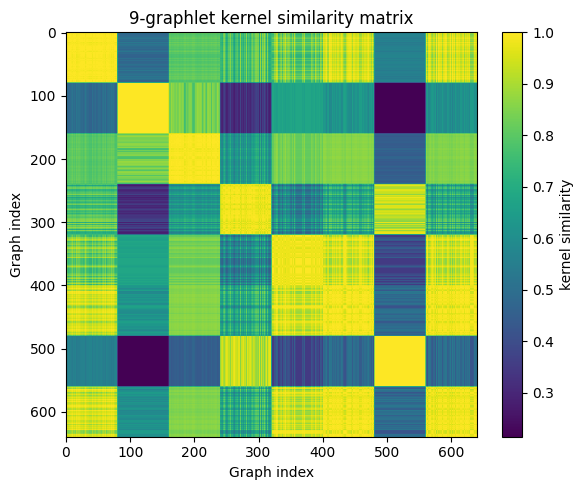

In [8]:
def normalize_kernel(K, eps=1e-12):
    diag = np.sqrt(np.maximum(np.diag(K), eps))
    return K / np.outer(diag, diag)

K9_raw = X9 @ X9.T
K9 = normalize_kernel(K9_raw)

print("9-graphlet kernel shape:", K9.shape)
print("Diagonal min/max:", np.diag(K9).min(), np.diag(K9).max()) # self-similarity 
print("Matrix min/max:", K9.min(), K9.max())

# Visualize the kernel after sorting graphs by class.
order = np.argsort(labels)
K_sorted = K9[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(K_sorted, aspect="auto")
ax.set_title("9-graphlet kernel similarity matrix")
ax.set_xlabel("Graph index")
ax.set_ylabel("Graph index")
fig.colorbar(im, ax=ax, label="kernel similarity")
plt.tight_layout()
plt.show()


## Step 7 : SVM classification with the 9-graphlet kernel

We train and evaluate once on the test set.


Split sizes:
 train: 512 [64 64 64 64 64 64 64 64]
 test:  128 [16 16 16 16 16 16 16 16]
Test accuracy: 0.930


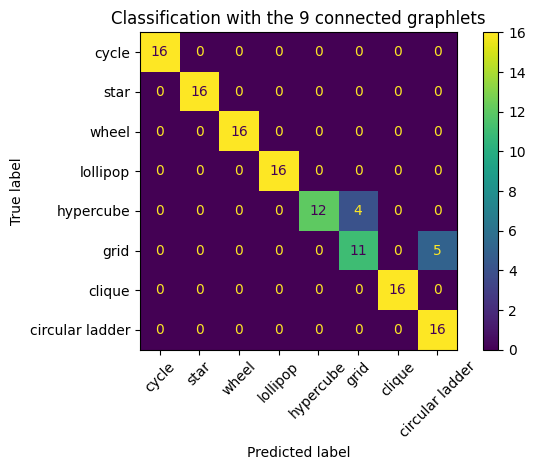

In [9]:
# Train / test split
indices = np.arange(len(dataset))
# 640 graphs -> 80/20 -> 512 train, 128 test
train_idx, test_idx = train_test_split(indices, test_size=128, stratify=labels)
print("Split sizes:")
print(" train:", len(train_idx), np.bincount(labels[train_idx]))
print(" test: ", len(test_idx), np.bincount(labels[test_idx]))

# Train an SVM using the graphlet kernel and evaluate on the test set
def classify_with_graphlet_kernel(K, y, train_idx, test_idx, C):
    K_train = K[np.ix_(train_idx, train_idx)]
    model = SVC(C=C, kernel="precomputed")
    model.fit(K_train, y[train_idx])
    test_pred = model.predict(K[np.ix_(test_idx, train_idx)])
    test_acc = accuracy_score(y[test_idx], test_pred)
    return test_acc, test_pred

test_acc, test_pred = classify_with_graphlet_kernel(K9, labels, train_idx, test_idx, 100)
print(f"Test accuracy: {test_acc:.3f}")

# Display the confusion matrix on the test set
ConfusionMatrixDisplay.from_predictions(labels[test_idx], test_pred, display_labels=CLASS_NAMES, xticks_rotation=45)
plt.title("Classification with the 9 connected graphlets")
plt.tight_layout()
plt.show()


## Remarks

- There exists a library for graphlets kernel (where disconnected subgraphs are not ignored): https://github.com/ysig/GraKeL
- This graph-level graphlet representation differs from the Graphlet Degree Vector (GDV), where graphlet orbits are counted separately for each node.
- How can we improve the performance on this simple dataset?
